# Crawling & Analisis Data Polutan Udara di Kabupaten Bangkalan

Nama :Moh Rafie Nazar J

NIM :240411100003

Mata Kuliah : Pengantar Sains Data (PSD)

## Latar Belakang

Kabupaten Bangkalan merupakan salah satu kabupaten di Provinsi Jawa Timur yang memiliki karakteristik wilayah yang beragam, meliputi sektor pertanian (padi, jagung, dan tambak ikan), peternakan, perikanan, serta aktivitas industri dan perdagangan yang terus berkembang. Beberapa industri yang beroperasi di Bangkalan antara lain industri pengolahan hasil perikanan, industri makanan dan minuman, industri kayu, serta pembangkit listrik. Selain itu, wilayah Bangkalan dilalui jalur transportasi utama Pantai Utara (Pantura) Jawa yang memiliki intensitas lalu lintas kendaraan berat (truk dan bus) yang cukup tinggi. Sektor pertanian yang luas, khususnya lahan sawah, juga menjadi sumber emisi metana (CH4) yang signifikan, sementara aktivitas pembakaran lahan dan sampah berkontribusi pada peningkatan konsentrasi CO dan HCHO di atmosfer. Oleh karena itu, pemantauan konsentrasi polutan udara seperti Karbon Monoksida (CO), Nitrogen Dioksida (NO2), Formaldehida (HCHO), Ozon troposferik (O3), Sulfur Dioksida (SO2), dan Metana (CH4) menjadi penting untuk memahami kondisi kualitas udara di wilayah Kabupaten Bangkalan dari waktu ke waktu.


## 1. Business Understanding

### a. Tujuan

Tugas ini bertujuan untuk mengetahui sumber-sumber polutan serta kondisi/kualitas udara di wilayah Kabupaten Bangkalan, melalui proses crawling data satelit untuk enam jenis polutan (CO, NO2, HCHO, O3, SO2, CH4), eksplorasi data (data understanding), serta visualisasi data time series selama kurun waktu minimal satu tahun sebelum 31 Agustus 2026.

### b. Manfaat

Manfaat yang diharapkan dari tugas ini antara lain:

1. Memberikan gambaran mengenai pola dan tren konsentrasi masing-masing polutan di wilayah Bangkalan sepanjang waktu.
2. Membantu mengidentifikasi kemungkinan sumber dominan tiap polutan berdasarkan karakteristik wilayah Bangkalan (pertanian, peternakan, perikanan, transportasi, dan industri).
3. Menjadi bahan evaluasi awal terkait kondisi kualitas udara di wilayah tersebut.
4. Menjadi dasar bagi analisis lanjutan (preprocessing dan pemodelan) pada tahap berikutnya.
5. Melatih kemampuan pengambilan data dari sumber data satelit (remote sensing) serta praktik data understanding untuk data time series lingkungan.

### c. Kemungkinan Sumber Masing-Masing Polutan

| Polutan | Deskripsi Singkat | Kemungkinan Sumber di Bangkalan |
|---|---|---|
| **CO** (Karbon Monoksida) | Gas hasil pembakaran tidak sempurna bahan bakar fosil | Emisi kendaraan bermotor di jalur Pantura, pembakaran lahan pertanian/sampah, aktivitas industri pengolahan, kebakaran lahan |
| **NO2** (Nitrogen Dioksida) | Gas pencemar hasil pembakaran suhu tinggi | Emisi kendaraan berat di jalur Pantura, aktivitas industri dan pembangkit listrik, pembakaran bahan bakar fosil |
| **HCHO** (Formaldehida) | Senyawa organik volatil (VOC) hasil oksidasi hidrokarbon di atmosfer | Pembakaran lahan pertanian/biomassa, industri kayu dan pengolahan, emisi kendaraan, oksidasi VOC alami dari vegetasi pertanian yang luas |
| **O3** (Ozon troposferik) | Polutan sekunder, terbentuk dari reaksi fotokimia | Reaksi fotokimia antara NOx dan VOC dengan bantuan sinar matahari, terkait emisi kendaraan Pantura dan lahan pertanian yang luas |
| **SO2** (Sulfur Dioksida) | Gas hasil pembakaran bahan bakar yang mengandung sulfur | Pembangkit listrik, industri pengolahan, serta pembakaran bahan bakar fosil pada kendaraan dan aktivitas industri di Bangkalan |
| **CH4** (Metana) | Gas rumah kaca, salah satu VOC utama | Lahan persawahan yang sangat luas (Bangkalan adalah penghasil padi terbesar Jawa Timur), peternakan sapi dan unggas, tempat pembuangan akhir (TPA) sampah, serta tambak ikan |

### d. Deskripsi Data

Data yang digunakan pada tugas ini bersumber dari citra satelit **Sentinel-5P TROPOMI** (Tropospheric Monitoring Instrument) yang dikelola oleh European Space Agency (ESA) di bawah program Copernicus, diakses melalui platform **Copernicus Data Space Ecosystem** menggunakan pustaka `openeo` pada Python dengan koleksi data `SENTINEL_5P_L2`.

Setiap band (CO, NO2, HCHO, O3, SO2, CH4) merepresentasikan nilai kolom vertikal (*total column density*) gas tersebut di atmosfer, pada satuan **mol/m²**, dengan resolusi spasial berkisar antara 5.5×3.5 km hingga 7×7 km tergantung jenis produknya, dan resolusi temporal harian (satu kali lintasan per hari untuk wilayah tertentu, dengan kemungkinan data kosong pada beberapa hari akibat tutupan awan).

Perlu dicatat bahwa pada implementasi openEO/Sentinel Hub API saat ini, satu permintaan data (`load_collection`) hanya dapat memuat **satu band/jenis polutan** untuk koleksi Sentinel-5P L2 — sehingga proses crawling keenam polutan pada tugas ini dilakukan secara terpisah (loop) satu per satu, dan hasilnya diunduh sebagai berkas NetCDF (`.nc`) terpisah untuk masing-masing polutan.


## 2. Penentuan Wilayah Kajian (Area of Interest) Menggunakan GeoJSON.io

Wilayah kajian ditentukan menggunakan berkas **GeoJSON** berbentuk polygon yang mencakup wilayah Kabupaten Bangkalan (dan sekitarnya), digambar melalui [geojson.io](https://geojson.io) kemudian disimpan sebagai berkas `.geojson` dan dibaca kembali menggunakan Python untuk membatasi wilayah pengambilan data pada tahap crawling.

In [ ]:
import json

# GeoJSON wilayah kajian (Kabupaten Bangkalan)
# ================================================================
# Polygon dibuat berdasarkan bounding box wilayah Bangkalan.
# Format koordinat: [longitude, latitude].
# Jika dosen meminta batas administrasi yang lebih presisi,
# polygon ini dapat diganti dengan GeoJSON hasil gambar di geojson.io.
# ================================================================

aoi_geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [112.674103, -7.217445],
                    [113.147072, -7.217445],
                    [113.147072, -6.878810],
                    [112.674103, -6.878810],
                    [112.674103, -7.217445]
                ]]
            }
        }
    ]
}

with open("aoi_bangkalan.geojson", "w") as f:
    json.dump(aoi_geojson, f, indent=2)

print("Berkas aoi_bangkalan.geojson berhasil disimpan.")


Berkas aoi_bangkalan.geojson berhasil disimpan.


In [ ]:
with open("aoi_bangkalan.geojson", "r") as f:
    aoi_geojson = json.load(f)

polygon_coords = aoi_geojson["features"][0]["geometry"]["coordinates"][0]
lons = [c[0] for c in polygon_coords]
lats = [c[1] for c in polygon_coords]

bbox = {
    "west": min(lons),
    "south": min(lats),
    "east": max(lons),
    "north": max(lats)
}

print("Bounding box wilayah kajian (Bangkalan):")
print(bbox)

Bounding box wilayah kajian (Bangkalan):
{'west': 112.674103, 'south': -7.217445, 'east': 113.147072, 'north': -6.87881}


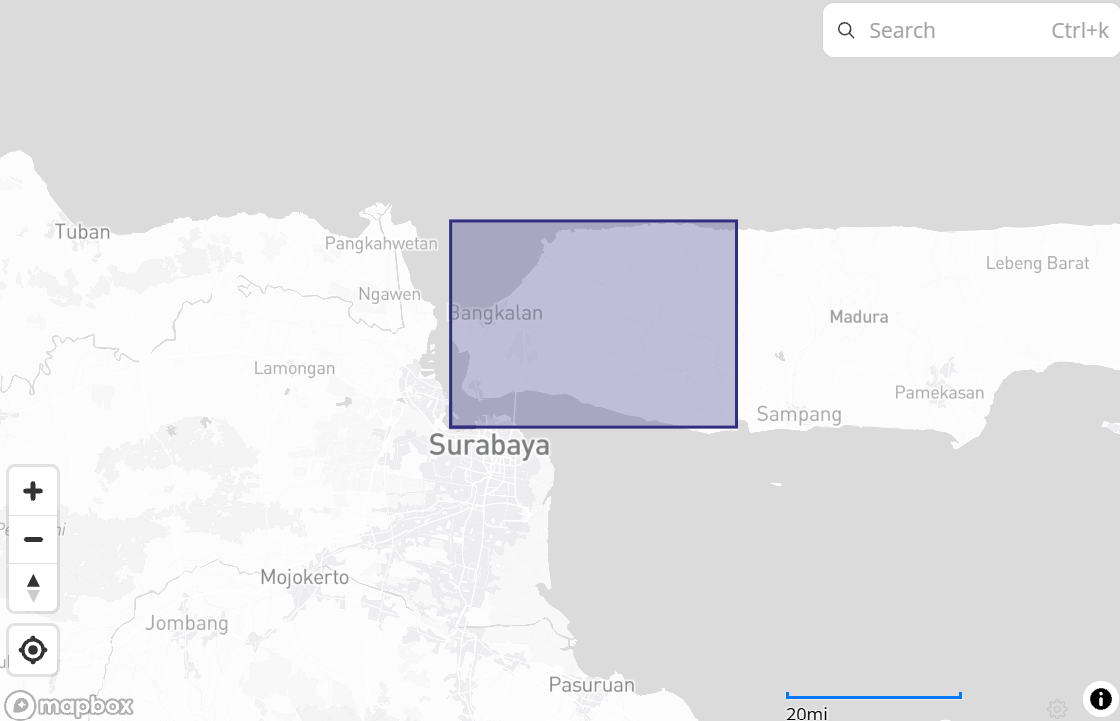

## 3. Data Collection (Crawling Data)

### a. Instalasi Library dan Koneksi ke Copernicus Data Space Ecosystem

In [ ]:
pip install openeo

In [ ]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


### b. Crawling Enam Polutan (CO, NO2, HCHO, O3, SO2, CH4)

Rentang waktu pengamatan ditentukan minimal satu tahun hingga tanggal 31 Agustus 2026, sesuai ketentuan tugas. Karena satu permintaan hanya dapat memuat satu band, proses crawling dilakukan melalui perulangan (`loop`) untuk setiap polutan, dan masing-masing hasil diunduh sebagai berkas NetCDF terpisah.

**Catatan:** apabila notebook ini dijalankan sebelum tanggal 31 Agustus 2026, data yang tersedia hanya akan mencakup tanggal terbaru yang sudah direkam satelit pada saat crawling dijalankan. Notebook perlu dijalankan ulang mendekati/sesudah tanggal tersebut agar rentang data benar-benar lengkap.

In [ ]:
pollutants = ["CO", "NO2", "HCHO", "O3", "SO2", "CH4"]

start_date = "2025-08-29"
end_date = "2026-08-31"

for pol in pollutants:
    cube = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[start_date, end_date],
        spatial_extent=bbox,
        bands=[pol],
    )
    cube_daily = cube.aggregate_temporal_period(reducer="mean", period="day")
    cube_daily.execute_batch(title=f"{pol} in Bangkalan", outputfile=f"{pol}_Bangkalan.nc")
    print(f"Selesai mengunduh data {pol} -> {pol}_Bangkalan.nc")

0:00:00 Job 'j-26083001505949508f0310f2c0b9c784': send 'start'
0:00:02 Job 'j-26083001505949508f0310f2c0b9c784': queued (progress 0%)
0:00:07 Job 'j-26083001505949508f0310f2c0b9c784': queued (progress 0%)
0:00:14 Job 'j-26083001505949508f0310f2c0b9c784': queued (progress 0%)
0:00:22 Job 'j-26083001505949508f0310f2c0b9c784': queued (progress 0%)
0:00:32 Job 'j-26083001505949508f0310f2c0b9c784': queued (progress 0%)
0:00:45 Job 'j-26083001505949508f0310f2c0b9c784': queued (progress 0%)
0:01:01 Job 'j-26083001505949508f0310f2c0b9c784': queued (progress 0%)
0:01:20 Job 'j-26083001505949508f0310f2c0b9c784': running (progress N/A)
0:01:44 Job 'j-26083001505949508f0310f2c0b9c784': running (progress N/A)
0:02:14 Job 'j-26083001505949508f0310f2c0b9c784': running (progress N/A)
0:02:51 Job 'j-26083001505949508f0310f2c0b9c784': running (progress N/A)
0:03:38 Job 'j-26083001505949508f0310f2c0b9c784': running (progress N/A)
0:04:37 Job 'j-26083001505949508f0310f2c0b9c784': finished (progress 100%)


Proses pengambilan data dapat dipantau pada halaman https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2, yang menampilkan status job serta dataset yang sedang diproses untuk masing-masing polutan.

## 4. Data Understanding

### a. Membaca Seluruh Berkas NetCDF dan Menyimpan ke CSV

Setiap berkas NetCDF hasil crawling dibaca, dihitung rata-rata nilai per hari untuk seluruh grid dalam wilayah kajian, kemudian disimpan ke dalam berkas CSV terpisah untuk masing-masing polutan.

In [ ]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.8 MB/s eta 0:00:00


In [ ]:
import netCDF4
import numpy as np
import pandas as pd

def read_daily_mean(band_name, filename):
    ds = netCDF4.Dataset(filename)

    values = ds.variables[band_name][:]
    time = ds.variables["t"][:]
    time_units = ds.variables["t"].units

    dates = netCDF4.num2date(
        time,
        units=time_units
    )

    daily_dates = [
        d.strftime("%Y-%m-%d")
        for d in dates
    ]

    daily_mean = []

    for i in range(len(values)):

        # Ambil satu hari
        data_harian = values[i]

        # Hitung mean dengan mengabaikan masked value
        mean_value = np.ma.mean(data_harian)

        # Ubah masked menjadi NaN
        if np.ma.is_masked(mean_value):
            mean_value = np.nan
        else:
            mean_value = float(mean_value)

        daily_mean.append(mean_value)

    df = pd.DataFrame({
        "date": daily_dates,
        band_name: daily_mean
    })

    df["date"] = pd.to_datetime(df["date"])

    # Pastikan benar-benar numeric
    df[band_name] = pd.to_numeric(
        df[band_name],
        errors="coerce"
    )

    return df

# Membaca semua data polutan
dataframes = {}

for pol in pollutants:
    df_pol = read_daily_mean(
        pol,
        f"{pol}_Bangkalan.nc"
    )

    dataframes[pol] = df_pol

    print(
        f"{pol}: {df_pol.shape[0]} baris data berhasil dibaca"
    )


# ==========================================
# GABUNGKAN LANGSUNG BERDASARKAN TANGGAL
# ==========================================

merged_df = dataframes[pollutants[0]][["date"]].copy()

for pol in pollutants:
    merged_df = merged_df.merge(
        dataframes[pol][["date", pol]],
        on="date",
        how="outer"
    )

# Urutkan berdasarkan tanggal
merged_df = merged_df.sort_values(
    "date"
).reset_index(drop=True)


# ==========================================
# SIMPAN HANYA SATU CSV
# ==========================================

merged_df.to_csv(
    "all_polutan_Bangkalan_timeseries.csv",
    index=False
)

print("\nData berhasil disimpan!")
print("Nama file: all_polutan_Bangkalan_timeseries.csv")
print("Jumlah baris:", len(merged_df))
print("Kolom:", merged_df.columns.tolist())

display(merged_df.head())

CO: 366 baris data berhasil dibaca
NO2: 364 baris data berhasil dibaca
HCHO: 362 baris data berhasil dibaca
O3: 362 baris data berhasil dibaca
SO2: 362 baris data berhasil dibaca
CH4: 215 baris data berhasil dibaca

Data berhasil disimpan!
Nama file: all_polutan_Bangkalan_timeseries.csv
Jumlah baris: 366
Kolom: ['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']


,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-29,0.026103,0.000026,0.000143,0.113214,8.791764e-05,1843.975260
1,2025-08-30,0.025363,0.000020,0.000077,0.115004,8.026050e-07,NaN
2,2025-08-31,0.025741,0.000013,0.000124,0.115688,6.201892e-06,NaN
3,2025-09-01,0.026722,0.000017,0.000082,0.115264,3.424412e-05,NaN
4,2025-09-02,0.024523,0.000012,0.000047,0.113861,-2.543385e-05,1837.764526


### b. Mengecek Struktur dan Isi Data

Untuk masing-masing polutan, diperiksa struktur data (tipe kolom, jumlah baris) serta beberapa baris pertama untuk memastikan hasil crawling sesuai yang diharapkan.

In [ ]:
print("=== Struktur Data Polutan Bangkalan ===")
merged_df.info()

print("\n=== Ukuran Dataset ===")
print("Jumlah baris :", merged_df.shape[0])
print("Jumlah kolom :", merged_df.shape[1])

print("\n=== Nama Kolom ===")
print(merged_df.columns.tolist())

print("\n=== 5 Data Pertama ===")
display(merged_df.head())

print("\n=== 5 Data Terakhir ===")
display(merged_df.tail())

=== Struktur Data Polutan Bangkalan ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    366 non-null    datetime64[ns]
 1   CO      278 non-null    float64       
 2   NO2     292 non-null    float64       
 3   HCHO    331 non-null    float64       
 4   O3      362 non-null    float64       
 5   SO2     322 non-null    float64       
 6   CH4     84 non-null     float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 20.1 KB

=== Ukuran Dataset ===
Jumlah baris : 366
Jumlah kolom : 7

=== Nama Kolom ===
['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']

=== 5 Data Pertama ===


,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-29,0.026103,0.000026,0.000143,0.113214,8.791764e-05,1843.975260
1,2025-08-30,0.025363,0.000020,0.000077,0.115004,8.026050e-07,NaN
2,2025-08-31,0.025741,0.000013,0.000124,0.115688,6.201892e-06,NaN
3,2025-09-01,0.026722,0.000017,0.000082,0.115264,3.424412e-05,NaN
4,2025-09-02,0.024523,0.000012,0.000047,0.113861,-2.543385e-05,1837.764526



=== 5 Data Terakhir ===


,date,CO,NO2,HCHO,O3,SO2,CH4
361,2026-08-25,0.029568,0.000022,0.000135,0.120986,0.000087,1895.163628
362,2026-08-26,0.030068,0.000026,0.000172,0.119329,0.000160,1895.771369
363,2026-08-27,0.029916,0.000029,0.000146,0.117706,0.000044,1892.712891
364,2026-08-28,0.036505,0.000030,0.000184,0.115545,-0.000091,1895.635800
365,2026-08-29,0.037011,0.000022,0.000126,0.115679,-0.000052,NaN


### c. Mengecek Missing Value

Missing value pada data Sentinel-5P umumnya terjadi akibat tutupan awan (*cloud cover*) yang menghalangi pengukuran satelit, sehingga sensor tidak mencatat nilai valid pada tanggal tertentu.

In [ ]:
print(f"{'Polutan':<8}{'Jumlah Baris':<15}{'Missing Value':<15}{'Persentase':<10}")

for pol in pollutants:
    n_total = len(merged_df)
    n_missing = merged_df[pol].isna().sum()
    pct = n_missing / n_total * 100 if n_total > 0 else 0
    print(f"{pol:<8}{n_total:<15}{n_missing:<15}{pct:.2f}%")

Polutan Jumlah Baris   Missing Value  Persentase
CO      366            88             24.04%
NO2     366            74             20.22%
HCHO    366            35             9.56%
O3      366            4              1.09%
SO2     366            44             12.02%
CH4     366            282            77.05%


### d. Mengecek Data Aneh / Outlier

Statistik deskriptif dan deteksi outlier menggunakan metode *Interquartile Range* (IQR) digunakan untuk mengidentifikasi nilai yang berada jauh di luar sebaran normal data, termasuk mengecek kewajaran nilai (apakah terdapat nilai negatif ekstrem yang tidak wajar secara fisis).

In [ ]:
summary_rows = []

for pol in pollutants:

    # Ambil kolom polutan dari dataset utama
    series = merged_df[pol].dropna()

    # Kuartil
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    # IQR
    IQR = Q3 - Q1

    # Batas outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Jumlah outlier
    n_outliers = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    summary_rows.append({
        "Polutan": pol,
        "Min": series.min(),
        "Max": series.max(),
        "Mean": series.mean(),
        "Std": series.std(),
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Batas Bawah": lower_bound,
        "Batas Atas": upper_bound,
        "Jumlah Outlier IQR": n_outliers
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,Polutan,Min,Max,Mean,Std,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier IQR
0,CO,0.020487,0.043208,0.028638,0.002850,0.026675,0.030160,0.003485,0.021448,0.035387,7
1,NO2,0.000004,0.000109,0.000025,0.000011,0.000019,0.000030,0.000011,0.000003,0.000046,8
2,HCHO,-0.000181,0.000622,0.000166,0.000083,0.000122,0.000198,0.000076,0.000009,0.000311,23
3,O3,0.110552,0.122840,0.115803,0.002287,0.114112,0.117330,0.003218,0.109284,0.122158,2
4,SO2,-0.000862,0.000381,0.000037,0.000124,-0.000013,0.000097,0.000110,-0.000178,0.000262,25
5,CH4,1674.215576,1938.674194,1867.935225,40.667591,1846.055206,1896.012959,49.957753,1771.118577,1970.949588,2


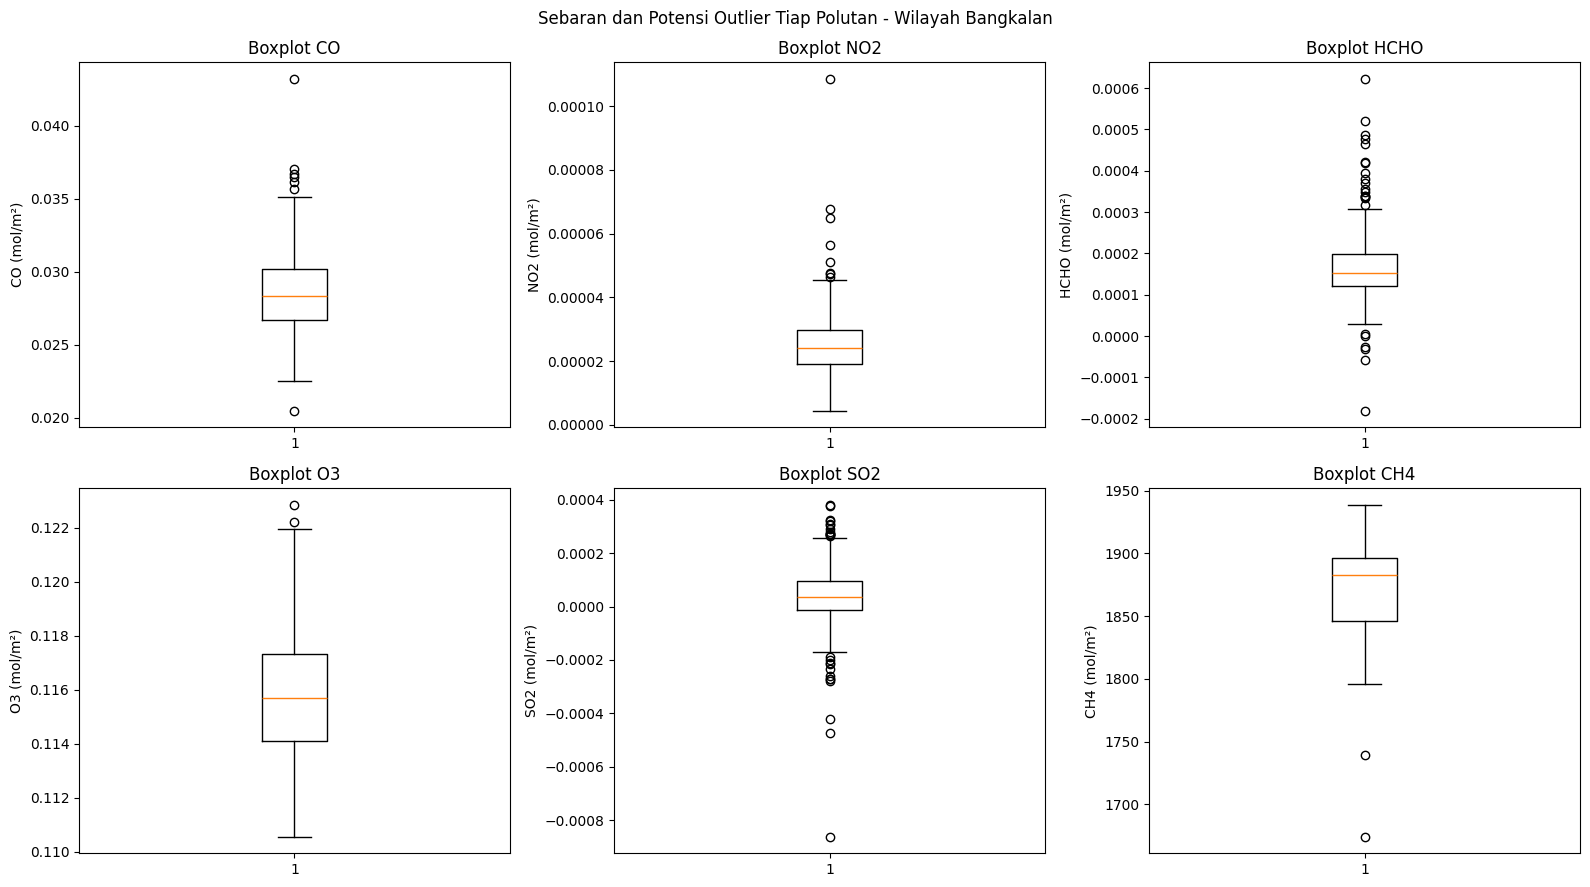

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, pol in zip(axes.flatten(), pollutants):
    ax.boxplot(
        merged_df[pol].dropna()
    )
    ax.set_title(f"Boxplot {pol}")
    ax.set_ylabel(f"{pol} (mol/m²)")

plt.suptitle(
    "Sebaran dan Potensi Outlier Tiap Polutan - Wilayah Bangkalan"
)

plt.tight_layout()
plt.show()

## 5. Visualisasi Time Series

Grafik berikut menampilkan perubahan konsentrasi masing-masing polutan di wilayah Kabupaten Bangkalan dari waktu ke waktu, menggunakan data harian hasil crawling (tanpa tahap pembersihan lebih lanjut, sesuai lingkup tugas ini yang berhenti pada tahap Data Understanding).

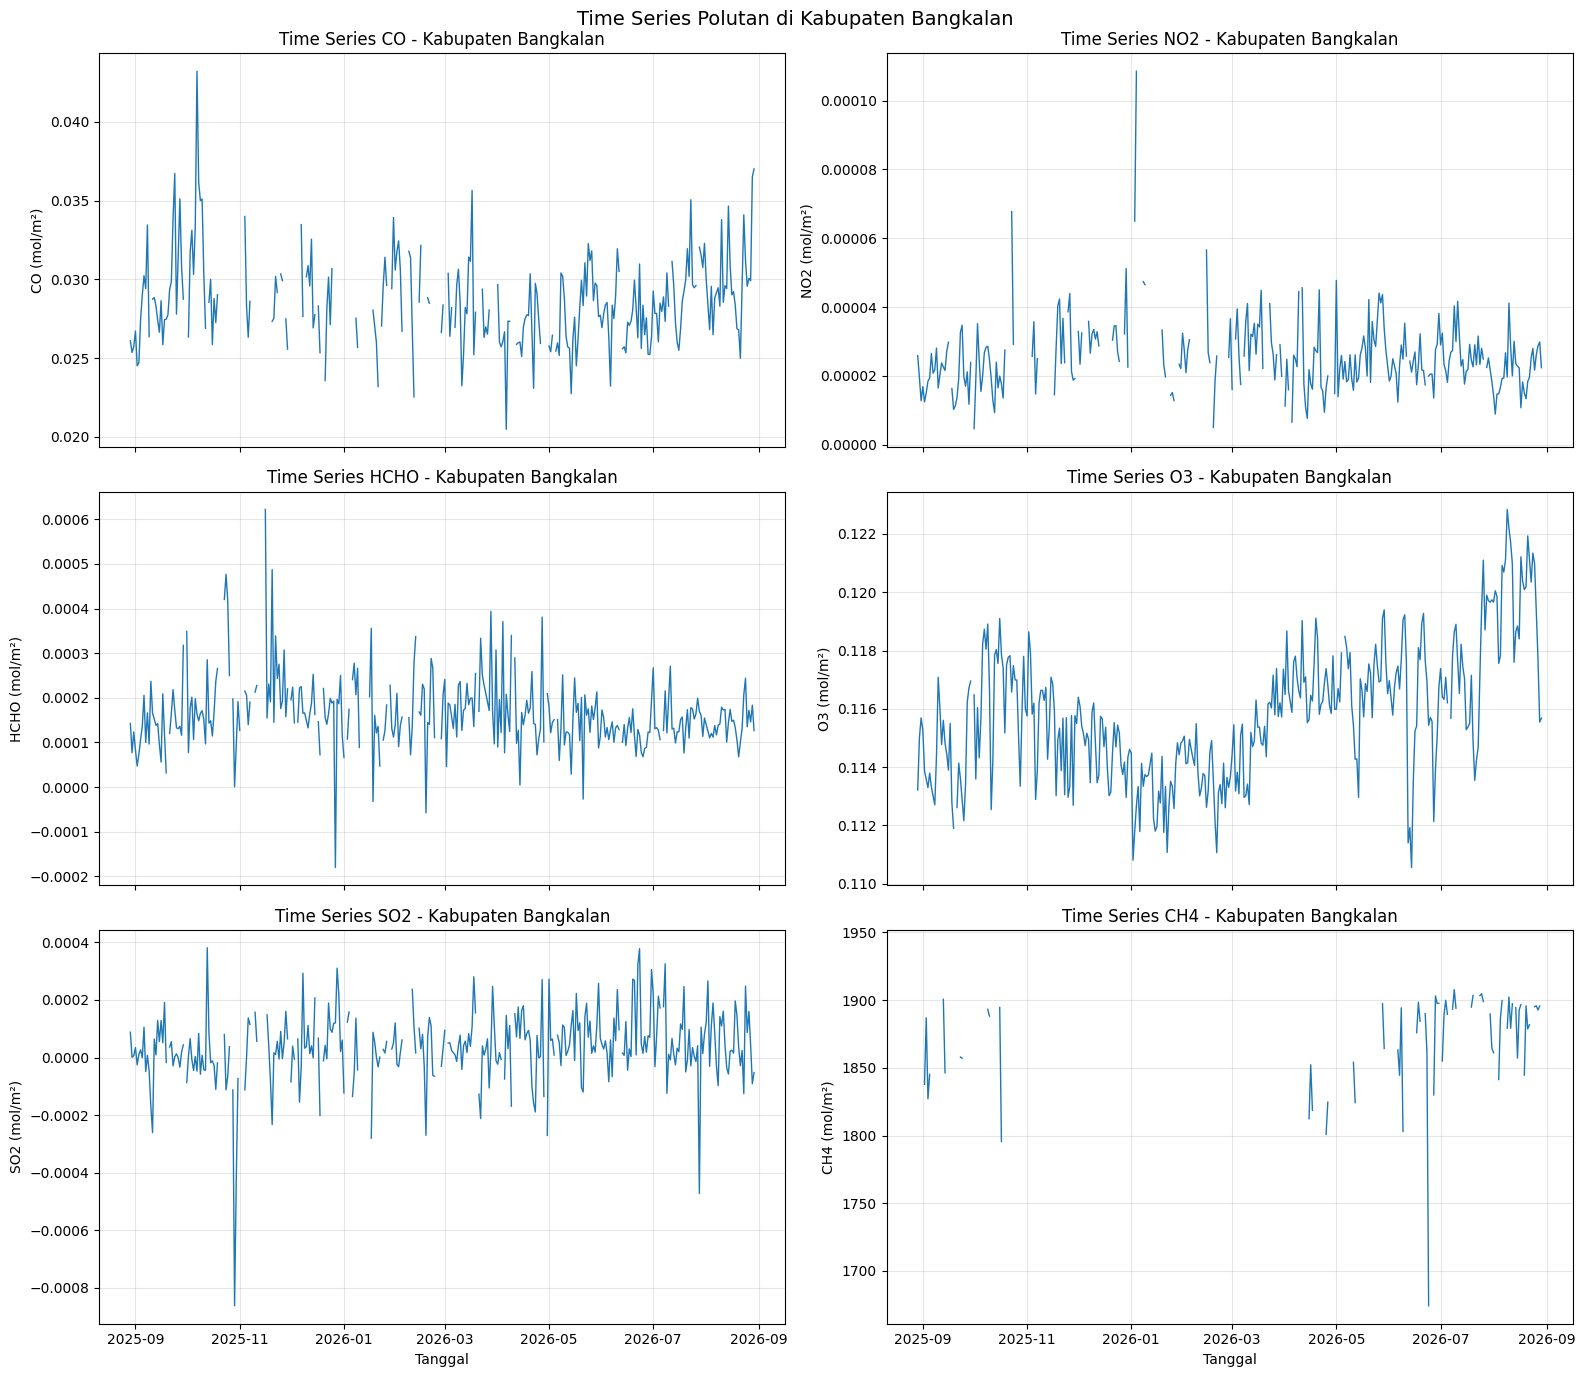

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 14),
    sharex=True
)

for ax, pol in zip(axes.flatten(), pollutants):
    ax.plot(
        merged_df["date"],
        merged_df[pol],
        linewidth=1
    )
    ax.set_title(
        f"Time Series {pol} - Kabupaten Bangkalan"
    )
    ax.set_ylabel(
        f"{pol} (mol/m²)"
    )
    ax.grid(alpha=0.3)

axes[-1, 0].set_xlabel("Tanggal")
axes[-1, 1].set_xlabel("Tanggal")

plt.suptitle(
    "Time Series Polutan di Kabupaten Bangkalan",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 6. Unduh Dataset

Dataset hasil crawling polutan udara di Kabupaten Bangkalan tersedia untuk diunduh dalam format CSV. Klik tombol di bawah untuk mengunduh berkas secara langsung.


In [ ]:
# Salin CSV terbaru ke _static/ agar tersedia di HTML build
import shutil, os
csv_file = 'all_polutan_Bangkalan_timeseries.csv'
static_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), '_static')
os.makedirs(static_dir, exist_ok=True)
if os.path.exists(csv_file):
    shutil.copy2(csv_file, os.path.join(static_dir, csv_file))
    print(f'CSV disalin ke _static/')


CSV disalin ke _static/


<div style="margin:20px 0;padding:20px;
background:linear-gradient(135deg,#f0f4ff,#e8f0fe);
border-radius:12px;border-left:5px solid #4285f4;
font-family:Arial,sans-serif;">

<p style="margin:0 0 6px 0;font-weight:bold;color:#1a1a1a;font-size:15px;">
Dataset Polutan Udara - Kabupaten Bangkalan
</p>

<p style="margin:0 0 14px 0;color:#555;font-size:13px;">
Format CSV &nbsp;|&nbsp; Polutan: CO, NO2, HCHO, O3, SO2, CH4
</p>

<a href="_static/all_polutan_Bangkalan_timeseries.csv"
   download="all_polutan_Bangkalan_timeseries.csv"
   style="display:inline-block;padding:10px 24px;
   background:linear-gradient(135deg,#4285f4,#1a73e8);
   color:white;text-decoration:none;border-radius:8px;
   font-weight:bold;font-size:14px;
   box-shadow:0 2px 8px rgba(66,133,244,0.4);">
   &#11015; Download CSV
</a>

</div>


## Kesimpulan

Berdasarkan rancangan dan proses pada notebook ini, data konsentrasi enam jenis polutan udara (CO, NO2, HCHO, O3, SO2, dan CH4) di wilayah **Kabupaten Bangkalan** akan diperoleh melalui proses crawling data satelit Sentinel-5P menggunakan pustaka OpenEO. Wilayah kajian dibatasi menggunakan GeoJSON dan data hasil crawling kemudian diolah menjadi data harian serta digabungkan ke dalam satu dataset CSV.

Enam polutan yang dianalisis meliputi **CO, NO2, HCHO, O3, SO2, dan CH4**. Proses crawling dilakukan menggunakan perulangan karena setiap permintaan data hanya mengambil satu band/polutan. Hasil setiap polutan disimpan dalam berkas NetCDF, kemudian dibaca kembali untuk memperoleh nilai rata-rata harian wilayah kajian.

Tahap **Data Understanding** mencakup pemeriksaan struktur dataset, jumlah data, missing value, statistik deskriptif, serta deteksi outlier menggunakan metode **Interquartile Range (IQR)**. Visualisasi time series digunakan untuk melihat perubahan nilai masing-masing polutan dari waktu ke waktu.

**Catatan:** seluruh output pada notebook ini (jumlah missing value, jumlah outlier, nilai minimum/maksimum, serta pola time series) baru akan terisi dan valid setelah notebook dijalankan (*run all*) dari awal hingga akhir menggunakan kredensial Copernicus Data Space milik masing-masing, sehingga proses crawling benar-benar mengambil data satelit terbaru untuk wilayah Kabupaten Bangkalan.

Dengan demikian, notebook ini dapat digunakan sebagai dasar untuk melakukan crawling dan analisis awal kualitas udara di Kabupaten Bangkalan selama periode pengamatan minimal satu tahun.
